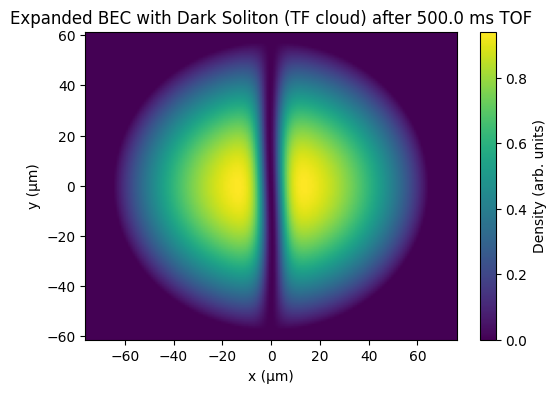

In [34]:
# Synthetic BEC dataset with traveling soliton and expansion
# Using full 3D Thomas-Fermi profile for the BEC

import numpy as np
import matplotlib.pyplot as plt

# ---------------------- Parameters ----------------------
# Grid along x (axial) and y (transverse)
x = 0.93 * np.linspace(-164//2, 164//2, 164)
y = 0.93 * np.linspace(-132//2, 132//2, 132)  # microns
X, Y = np.meshgrid(x, y)

# Trap and cloud parameters
Rx0 = 65.0  # axial Thomas-Fermi radius (µm)
Ry0 = 58.0   # transverse Thomas-Fermi radius (µm)

# Soliton parameters
n0 = 1.0      # peak density
xi = 5.0      # healing length (microns)
v_s = 2.0    # soliton speed along x (µm/ms)
phase_jump = np.pi

# ---------------------- 2D Thomas-Fermi profile ----------------------
# 2D circular TF cloud: n(x,y) = n0 * (1 - (x/Rx0)^2 - (y/Ry0)^2) for inside cloud, 0 outside
density_TF = np.clip(n0 * (1 - (X/Rx0)**2 - (Y/Ry0)**2), 0, None)

# ---------------------- Soliton function ----------------------
def dark_soliton(x, t, xi, v_s, n0, phase_jump):
    depth = np.sin(phase_jump/2)
    width = xi / depth
    x_shift = v_s * t
    return n0 * (1 - depth**2 * np.cosh((x-x_shift)/width)**-2)

# ---------------------- Soliton plane with bending ----------------------
bend_amplitude = -0.5
bend_wavelength = 100.0
X_soliton = X - bend_amplitude * np.sin(2 * np.pi * Y / bend_wavelength)

# 2D soliton density
soliton2D = dark_soliton(X_soliton, 0, xi, 0, n0, phase_jump)

# ---------------------- Combine soliton and TF cloud ----------------------
density2D = density_TF * soliton2D

# ---------------------- Simulate TOF expansion ----------------------
# Simple transverse scaling
Ry_exp = Ry0 * np.sqrt(1 + (12*2*np.pi/100)**2)
density2D *= np.exp(-(Y**2)/(2*Ry_exp**2))

# ---------------------- Plot expanded cloud ----------------------
plt.figure(figsize=(6, 4))
plt.imshow(density2D, extent=[x[0], x[-1], y[0], y[-1]], origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='Density (arb. units)')
plt.xlabel('x (µm)')
plt.ylabel('y (µm)')
plt.title(f'Expanded BEC with Dark Soliton (TF cloud) after {t_exp} ms TOF')
plt.show()